In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("titanic.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [3]:
df.shape

(891, 12)

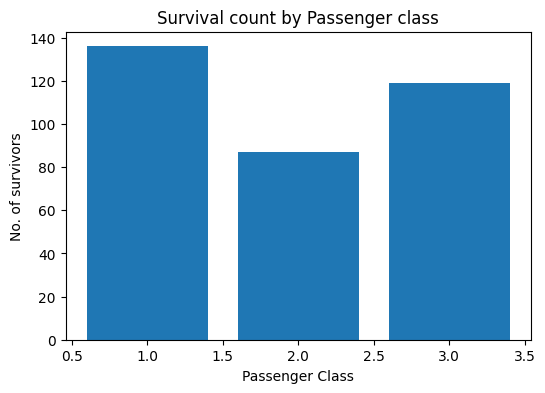

In [4]:
plt.figure(figsize=(6,4))
survived_by_class = df[df['Survived'] == 1]['Pclass'].value_counts().sort_index()
plt.bar(x=survived_by_class.index, height=survived_by_class.values)
plt.xlabel("Passenger Class")
plt.ylabel("No. of survivors")
plt.title("Survival count by Passenger class")
plt.savefig('plot.png')
plt.show()

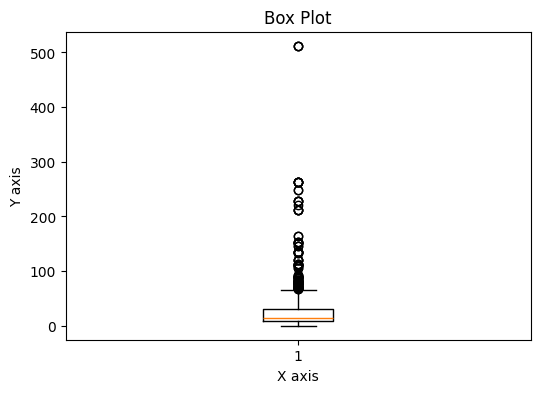

In [5]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Fare'])
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Box Plot")
plt.savefig('boxplot.svg', format="svg")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'])
y = df['Survived']
print(X.shape)
print(y.shape)

(891, 8)
(891,)


In [ ]:
# handling NaNs
X['Age'].fillna(X['Age'].median(), inplace=True)
X['Fare'].fillna(X['Fare'].median(), inplace=True)
X['Embarked'].fillna('S', inplace=True) 

In [9]:
# encoding categorical columns
X['Sex'] = X['Sex'].map({'male':0, 'female':1})
X['Embarked'] = X['Embarked'].map({'C':0, 'Q':1, 'S':2})

In [12]:
# split into training and testing set
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size= 0.2,random_state=123)
print(f'length of X_train and y_train = {X_train.shape}{y_train.shape}')
print(f'length of X_test and y_test = {X_test.shape}{y_test.shape}')

length of X_train and y_train = (712, 8)(712,)
length of X_test and y_test = (179, 8)(179,)


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [14]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.6424581005586593

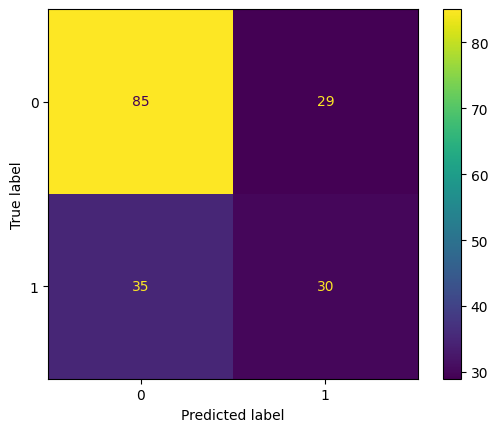

In [15]:
cm = confusion_matrix(y_test,y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=df['Survived'].unique())
cm_plot.plot()
plt.savefig("cm.png")
plt.show()

In [16]:
X_test

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
172,173,3,1,1.0,1,1,11.1333,2
524,525,3,0,28.0,0,0,7.2292,0
452,453,1,0,30.0,0,0,27.7500,0
170,171,1,0,61.0,0,0,33.5000,2
620,621,3,0,27.0,1,0,14.4542,0
...,...,...,...,...,...,...,...,...
388,389,3,0,28.0,0,0,7.7292,1
338,339,3,0,45.0,0,0,8.0500,2
827,828,2,0,1.0,0,2,37.0042,0
773,774,3,0,28.0,0,0,7.2250,0


In [ ]:
ans = knn.predict([[222,2,0,27.0,0,0,13,2]])
print(ans[0])

In [22]:
import joblib
joblib.dump(knn, 'knn_model.joblib')
print("Sucsess")

Sucsess
